#PhlyGreen Tutorial 

Import packages

In [744]:
import sys
sys.path.insert(0,'../')
import PhlyGreen as pg
import numpy as np
import matplotlib.pyplot as plt

Create instances of subsystems. Each one of those requires an Aircraft object as argument. By passing (None) as argument, we are creating empty objects (for the moment).

In [745]:
powertrain = pg.Systems.Powertrain.Powertrain(None)
structures = pg.Systems.Structures.Structures(None)
aerodynamics = pg.Systems.Aerodynamics.Aerodynamics(None)
performance = pg.Performance.Performance(None)
mission = pg.Mission.Mission(None)
weight = pg.Weight.Weight(None)
constraint = pg.Constraint.Constraint(None)
welltowake = pg.WellToWake.WellToWake(None)
battery = pg.Systems.Battery.Battery(None)
climateimpact = pg.ClimateImpact.ClimateImpact(None)

Create instance of Aircraft object.

In [746]:
myaircraft = pg.Aircraft(powertrain, structures, aerodynamics, performance, mission, weight, constraint, welltowake, battery, climateimpact)

Create the connections with its subsystems.

In [747]:
powertrain.aircraft = myaircraft
structures.aircraft = myaircraft
aerodynamics.aircraft = myaircraft
mission.aircraft = myaircraft
performance.aircraft = myaircraft
weight.aircraft = myaircraft
constraint.aircraft = myaircraft
welltowake.aircraft = myaircraft
battery.aircraft = myaircraft

Define input dictionaries

Constraints ordering:
[0] : cruise,
[1] : take-off,
[2] : climb,
[3] : turn,
[4] : ceiling,
[5] : acceleration,
[6] : landing 

In [748]:
ConstraintsInput = {'Cruise': {'Speed': 0.5, 'Speed Type':'Mach', 'Beta': 0.95, 'Altitude': 7620.},
         'AEO Climb': {'Speed': 190, 'Speed Type':'KCAS', 'Beta': 0.98, 'Altitude': 0., 'ROC': 12.7},
         'OEI Climb': {'Speed': 190, 'Speed Type': 'KCAS', 'Beta': 0.98, 'Altitude': 0., 'Climb Gradient': 0.021},
         'Take Off': {'Speed': 140, 'Speed Type': 'KCAS', 'Beta': 0.985, 'Altitude': 0., 'kTO': 1.2, 'sTO': 1500},
         'Landing':{'Speed': 115., 'Speed Type': 'KCAS', 'Altitude': 0.},
         'Turn':{'Speed': 210, 'Speed Type': 'KCAS', 'Beta': 0.9, 'Altitude': 5000, 'Load Factor': 1.1},
         'Ceiling':{'Speed': 0.5, 'Beta': 0.95, 'Altitude': 7620, 'HT': 0.5},
         'Acceleration':{'Mach 1': 0.3, 'Mach 2':0.4, 'DT': 180, 'Altitude': 6000, 'Beta': 0.9},
         'DISA': 10}

In [749]:
MissionInput = {'Range Mission': 600,  #nautical miles
                'Range Diversion': 200,  #nautical miles
                'Beta start': 0.985,
                'Payload Weight': 9752,  #Kg
                'Crew Weight': 340}  #Kg

In [750]:
MissionStages = {'Takeoff': {'Supplied Power Ratio':{'phi': 0.0}},
                 'Climb1': {'type': 'ConstantRateClimb', 'input': {'CB': 0.075, 'Speed': 93, 'StartAltitude': 0, 'EndAltitude': 2500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Climb2': {'type': 'ConstantRateClimb', 'input': {'CB': 0.066, 'Speed': 103, 'StartAltitude': 2500, 'EndAltitude': 4300}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Climb3': {'type': 'ConstantRateClimb', 'input': {'CB': 0.057, 'Speed': 113, 'StartAltitude': 4300, 'EndAltitude': 6100}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Climb4': {'type': 'ConstantRateClimb', 'input': {'CB': 0.05, 'Speed': 112, 'StartAltitude': 6100, 'EndAltitude': 7620}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Cruise': {'type': 'ConstantMachCruise', 'input':{ 'Mach': 0.45, 'Altitude': 7620}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0}},
                 'Descent1': {'type': 'ConstantRateDescent', 'input':{'CB': -0.05, 'Speed': 125, 'StartAltitude': 7620, 'EndAltitude': 4500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Descent2': {'type': 'ConstantRateDescent', 'input':{'CB': -0.05, 'Speed': 110, 'StartAltitude': 4500, 'EndAltitude': 3000}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Descent3': {'type': 'ConstantRateDescent', 'input':{'CB': -0.05, 'Speed': 87, 'StartAltitude': 3000, 'EndAltitude': 0}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }}
                 }

DiversionStages = {'Climb1': {'type': 'ConstantRateClimb', 'input': {'CB': 0.073, 'Speed': 93, 'StartAltitude': 0, 'EndAltitude': 2500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Climb2': {'type': 'ConstantRateClimb', 'input': {'CB': 0.066, 'Speed': 103, 'StartAltitude': 2500, 'EndAltitude': 4500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Cruise': {'type': 'ConstantMachCruise', 'input':{ 'Mach': 0.37, 'Altitude': 4500}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0}},
                 'Descent1': {'type': 'ConstantRateDescent', 'input':{'CB': -0.05, 'Speed': 110, 'StartAltitude': 4500, 'EndAltitude': 3000}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }},
                 'Descent2': {'type': 'ConstantRateDescent', 'input':{'CB': -0.05, 'Speed': 87, 'StartAltitude': 3000, 'EndAltitude': 0}, 'Supplied Power Ratio':{'phi_start': 0.0, 'phi_end':0.0 }}}

In [751]:
EnergyInput = {'Ef': 43.5*10**6,
                   'Contingency Fuel': 130,
                   #'Eta Gas Turbine Model': 'PW127',
                   'Eta Gas Turbine': 0.4,
                   'Eta Gearbox': 0.96,
                   'Eta Propulsive Model': 'constant',
                   'Eta Propulsive': 0.75,
                   'Specific Power Powertrain': [3900,7700],  # W/Kg
                   'Eta Electric Motor 1': 0.96,    #for serial config
                   'Eta Electric Motor 2': 0.96,    #for serial config
                   'Eta Electric Motor': 0.98,      #for parallel config
                   'Specific Power PMAD': [2200,2200,2200],
                   'PowertoWeight Powertrain': [150,33],
                   'PowertoWeight PMAD': 0,
                   'Eta PMAD': 0.99,
                   }

What follows is the battery cell input. Not used in this example.

In [752]:
CellInput = {
    'Class': "I",
    'Model':'Finger-Cell-Thermal',
    'SpecificPower': 8000,
    'SpecificEnergy': 1500,
    'Minimum SOC': 0.2,
    'Pack Voltage':800,
    'Initial temperature': 25,
    'Max operative temperature':50,
    'Ebat': 1000 * 3600, # PhlyGreen uses this input only if Class == 'I'
    'pbat': 1000
    }

In [753]:
AerodynamicsInput = {'NumericalPolar': {'type': 'ATR42'},
                    'Take Off Cl': 2.1,
                     'Landing Cl': 2.5,
                     'Minimum Cl': 0.20,
                     'Cd0': 0.017}

Import input dictionaries

In [754]:
myaircraft.ConstraintsInput = ConstraintsInput
myaircraft.AerodynamicsInput = AerodynamicsInput
myaircraft.MissionInput = MissionInput
myaircraft.MissionStages = MissionStages
myaircraft.DiversionStages = DiversionStages
myaircraft.EnergyInput = EnergyInput
myaircraft.CellInput = CellInput

Set aircraft power configuration

In [755]:
myaircraft.Configuration = 'Traditional'
#myaircraft.Configuration = 'Hybrid'
#myaircraft.HybridType = 'Parallel'
myaircraft.AircraftType = 'ATR'

Set inputs

In [756]:
# Initialize Constraint Analysis
myaircraft.constraint.SetInput()

# Initialize Mission profile and Analysis
myaircraft.mission.InitializeProfile()
myaircraft.mission.SetInput()

# Initialize Aerodynamics subsystem
myaircraft.aerodynamics.SetInput()

# Initialize Powertrain
myaircraft.powertrain.SetInput()

# Initialize Weight Estimator
myaircraft.weight.Class = 'I'

from FLOPS_input import FLOPS_input
myaircraft.FLOPSInput = FLOPS_input

myaircraft.weight.SetInput()

#Initialize Battery Configurator
myaircraft.battery.SetInput()

Either run the Constraint Analysis....

In [757]:
myaircraft.constraint.FindDesignPoint()
print('----------------------------------------')
print('Design W/S: ',myaircraft.DesignWTOoS)
print('Design P/W: ',myaircraft.DesignPW)
print('----------------------------------------')

----------------------------------------
Design W/S:  5024.306306306306
Design P/W:  174.37049269825883
----------------------------------------


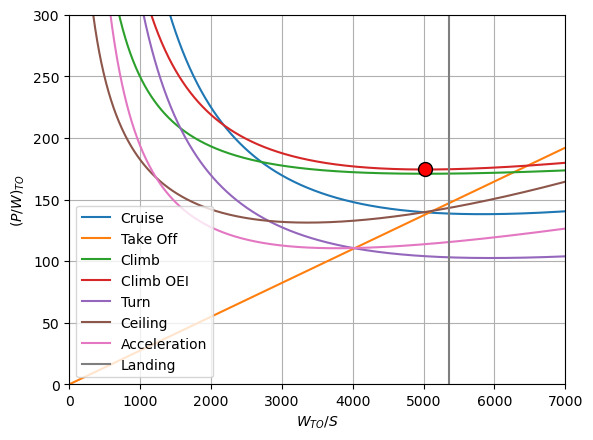

In [758]:
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWCruise, label='Cruise')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWTakeOff, label='Take Off')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWAEOClimb, label='Climb')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWOEIClimb, label='Climb OEI')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWTurn, label='Turn')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWCeiling, label='Ceiling')
plt.plot(myaircraft.constraint.WTOoS,myaircraft.constraint.PWAcceleration, label='Acceleration')
plt.plot(myaircraft.constraint.WTOoSLanding,myaircraft. constraint.PWLanding, label='Landing')
plt.plot(myaircraft.DesignWTOoS, myaircraft.DesignPW, marker='o', markersize = 10, markerfacecolor = 'red', markeredgecolor = 'black')
# plt.plot(performance.WTOoSTorenbeek, performance.PWTorenbeek, label='Torenbeek')
plt.ylim([0, 300])
plt.xlim([0, 7000])
plt.legend()
plt.grid(visible=True)
plt.xlabel('$W_{TO}/S$')
plt.ylabel('$(P/W)_{TO}$')
plt.show()

... or assign a wing loading. As a matter of fact, the constraint analysis gives only a rough estimate of the required propulsive power, upon which grounding the wing loading choice. The mission analysis will give more accurate estimates (but requires a wing loading)

In [759]:
#myaircraft.DesignWTOoS = 3300

Run Mission analysis to define the aircraft's masses

In [760]:
myaircraft.weight.WeightEstimation()

Wing surface can be readily estimated as S = WTO/(WTO/S)

In [761]:
myaircraft.WingSurface = myaircraft.weight.WTO / myaircraft.DesignWTOoS * myaircraft.performance.g_acc 

A summary of the preliminary design:

In [762]:
myaircraft.Print_Aircraft_Design_Summary()

Fuel mass (trip + altn + loiter): 1717.1 [Kg]
Block Fuel mass:                  1847.1 [Kg]
Structure:                        16351.4 [Kg]
Powertrain mass:                  2083.7 [Kg]
Empty Weight:                     18775.1 [Kg]
Zero Fuel Weight:                 28527.1 [Kg]
----------------------------------------
Takeoff Weight:                   30374.2 [Kg]
 
 
Wing Surface:                     59.3 [m^2]
 
TakeOff engine shaft peak power:  7356.1 [KW]
CLB/CRZ engine shaft peak power:  5069.2 [KW] @ 6091.8 [m]
 
Sizing phase for thermal powertrain:  Takeoff peak power
Thermal powertrain rating shaft power SLS rating: 8126.5 [kW]
 


In [763]:
myaircraft.mission.WTO * myaircraft.performance.TakeOff(
            myaircraft.DesignWTOoS,
            myaircraft.constraint.TakeOffConstraints['Beta'], 
            myaircraft.constraint.TakeOffConstraints['Altitude'], 
            myaircraft.constraint.TakeOffConstraints['kTO'], 
            myaircraft.constraint.TakeOffConstraints['sTO'], 
            myaircraft.constraint.DISA, 
            myaircraft.constraint.TakeOffConstraints['Speed'], 
            myaircraft.constraint.TakeOffConstraints['Speed Type'])

4187764.37183534

In [764]:
myaircraft.mission.WTO * myaircraft.performance.OEIClimb(
            myaircraft.DesignWTOoS, 
            myaircraft.constraint.OEIClimbConstraints['Beta'], 
            myaircraft.constraint.OEIClimbConstraints['Speed'] * myaircraft.constraint.OEIClimbConstraints['Climb Gradient'], 
            1., 
            myaircraft.constraint.OEIClimbConstraints['Altitude'], 
            myaircraft.constraint.DISA, 
            myaircraft.constraint.OEIClimbConstraints['Speed'], 
            myaircraft.constraint.OEIClimbConstraints['Speed Type'])

5296378.366822436

Some plots:

In [765]:
times = np.array([])
Ef = np.array([])
beta = np.array([])
for array in mission.integral_solution:
    times = np.concatenate([times, array.t])
    Ef = np.concatenate([Ef, array.y[0]])
    beta = np.concatenate([beta, array.y[1]])

Take-Off Propulsive Power over Takeoff Mass

In [766]:
myaircraft.performance.TakeOff(myaircraft.DesignWTOoS,myaircraft.constraint.TakeOffConstraints['Beta'], myaircraft.constraint.TakeOffConstraints['Altitude'],myaircraft.constraint.TakeOffConstraints['kTO'], myaircraft.constraint.TakeOffConstraints['sTO'], myaircraft.constraint.DISA, myaircraft.constraint.TakeOffConstraints['Speed'], myaircraft.constraint.TakeOffConstraints['Speed Type'])

137.8720488315943

Maximum mission Propusive Power over Takeoff Mass

In [767]:
max([myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))])

120.16137856795605

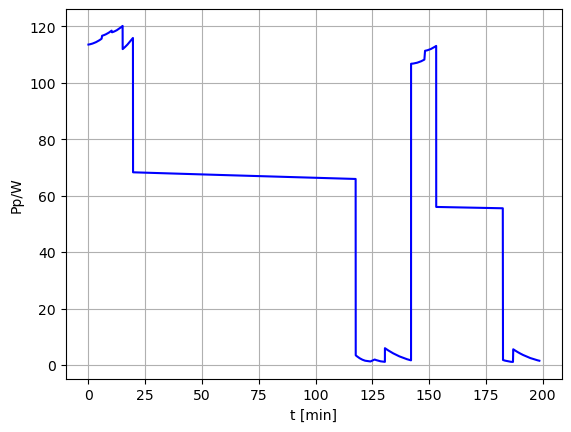

In [768]:
plt.plot(times/60,[myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))], 'b')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Pp/W')
plt.show()

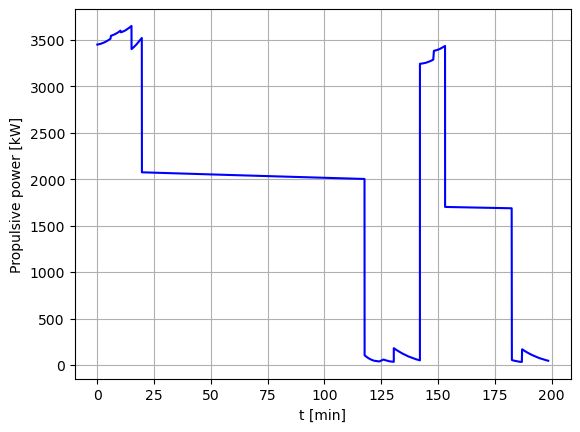

In [769]:
plt.plot(times/60,[(myaircraft.weight.WTO/1000) * myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))], 'b')
# pwsd[t]= 1e-3*0.5*0.89*(myaircraft.weight.WTO/1000) * myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Propulsive power [kW]')
plt.show()

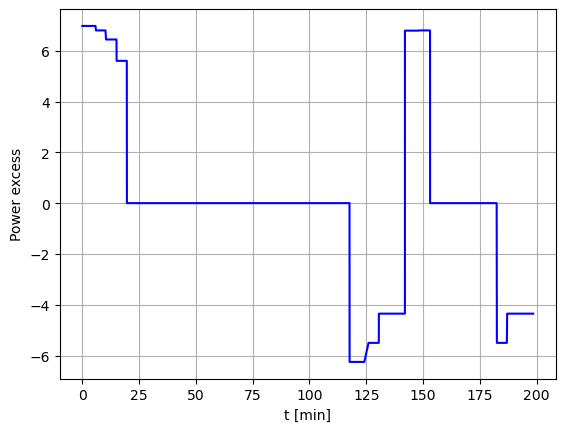

In [770]:
plt.plot(times/60,[myaircraft.mission.profile.PowerExcess(times[t]) for t in range(len(times))], 'b')
# pwsd[t]= 1e-3*0.5*0.89*(myaircraft.weight.WTO/1000) * myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,myaircraft.mission.profile.Altitude(times[t]),myaircraft.mission.DISA,myaircraft.mission.profile.Velocity(times[t]),'TAS') for t in range(len(times))
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Power excess')
plt.show()

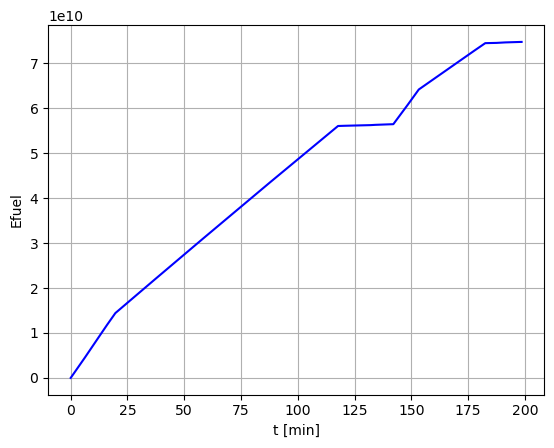

In [771]:
plt.plot(times/60,Ef, 'b')
#plt.plot(myaircraft.mission.profile.Breaks,np.ones(6)*0.05, '*')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Efuel')
plt.show()

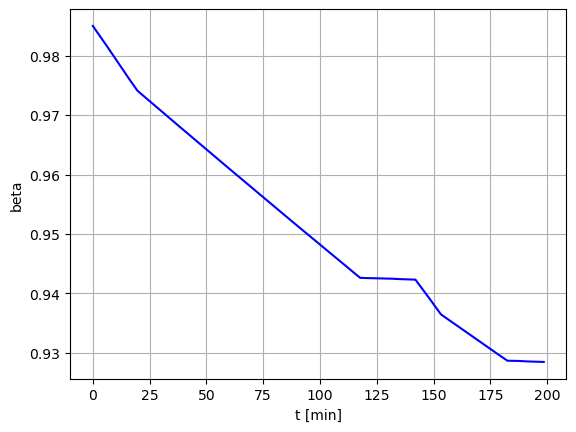

In [772]:
plt.plot(times/60,beta, 'b')
#plt.plot(myaircraft.mission.profile.Breaks,np.ones(6)*0.05, '*')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('beta')
plt.show()

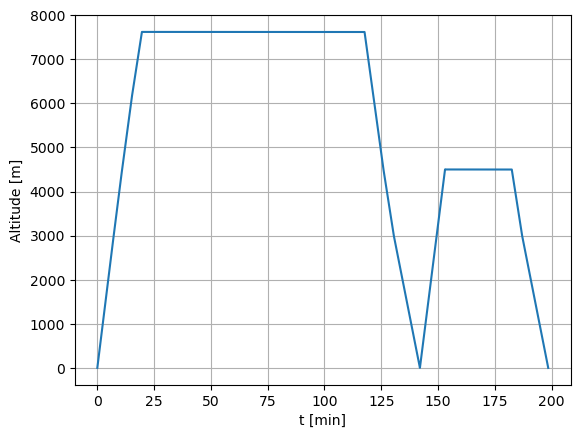

In [773]:
plt.plot(times/60,mission.profile.Altitude(times))
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('Altitude [m]')
plt.show()

Time to climb:

In [774]:
def time_to_climb(monotone_alt, h_cruise, t0=0.0, t_hi_init=1.0):
    """
    monotone_alt: function Altitude(t), strictly nondecreasing up to cruise
    Returns earliest t with Altitude(t) >= h_cruise.
    """
    # If already at/above cruise
    if monotone_alt(t0) >= h_cruise:
        return t0

    # 1) bracket by doubling until Alt(t_hi) >= h_cruise
    t_lo, t_hi = t0, t_hi_init
    f_lo = monotone_alt(t_lo) - h_cruise
    f_hi = monotone_alt(t_hi) - h_cruise
    while f_hi < 0.0:
        t_lo, f_lo = t_hi, f_hi
        t_hi *= 2.0
        f_hi = monotone_alt(t_hi) - h_cruise

    # 2) bisection on [t_lo, t_hi]
    for _ in range(60):
        t_mid = 0.5 * (t_lo + t_hi)
        if monotone_alt(t_mid) - h_cruise >= 0.0:
            t_hi = t_mid
        else:
            t_lo = t_mid
        if t_hi - t_lo <= 1e-6:
            break
    return t_hi

print('time to climb to 20000 ft (min): ',time_to_climb(mission.profile.Altitude, 6096)/60)
print('time to climb to 25000 ft (min): ',time_to_climb(mission.profile.Altitude, 7620)/60)

time to climb to 20000 ft (min):  15.047311496734618
time to climb to 25000 ft (min):  19.590476195017498


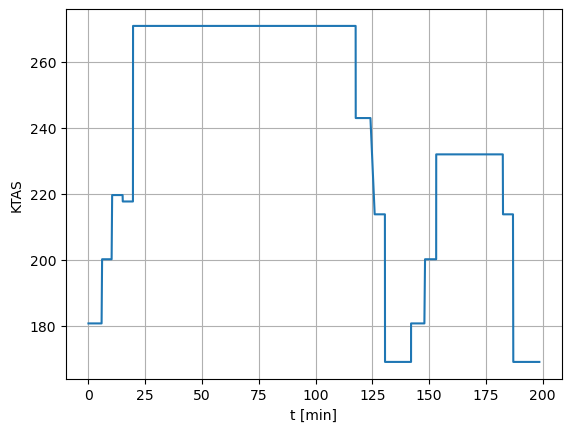

In [775]:
plt.plot(times/60,pg.Utilities.Units.MtoKN(mission.profile.Velocity(times)))
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('KTAS')
plt.show()

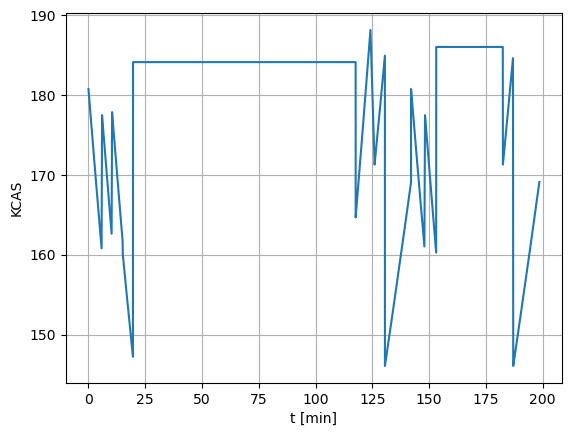

In [776]:
plt.plot(times/60,[pg.Utilities.Units.MtoKN(pg.Utilities.Speed.TAS2CAS(mission.profile.Velocity(t),mission.profile.Altitude(t))) for t in times])
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('KCAS')
plt.show()

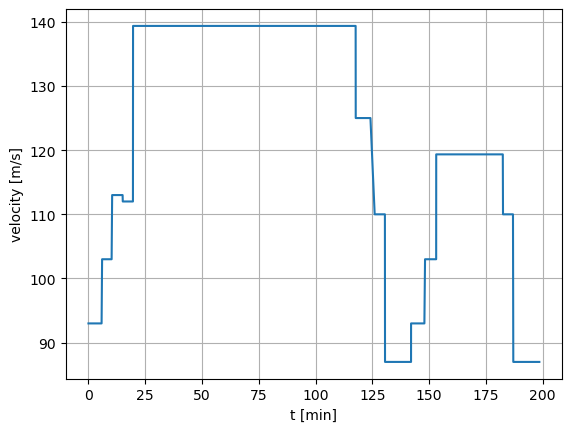

In [777]:
plt.plot(times/60,mission.profile.Velocity(times))
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('velocity [m/s]')
plt.show()

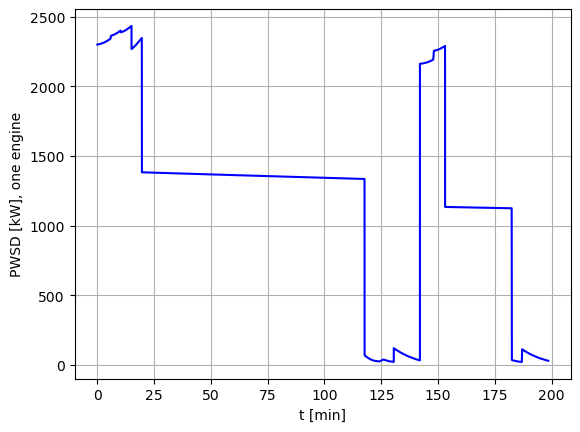

In [778]:
pwsd = np.zeros(len(times))
for t in range(len(times)):
    alt = myaircraft.mission.profile.Altitude(times[t])
    v = myaircraft.mission.profile.Velocity(times[t])
    power = (myaircraft.weight.WTO) * myaircraft.performance.PoWTO(myaircraft.DesignWTOoS,beta[t],myaircraft.mission.profile.PowerExcess(times[t]),1,alt,myaircraft.mission.DISA,v,'TAS')
    pwsd[t]= 1e-3*(1/myaircraft.performance.n_engines)*power/myaircraft.powertrain.EtaPP
plt.plot(times/60,pwsd, 'b')
plt.grid(visible=True)
plt.xlabel('t [min]')
plt.ylabel('PWSD [kW], one engine')
plt.show()